In [1]:
import os
import importlib.util
from pathlib import Path

# Remove previously forced PROJ paths
os.environ.pop("PROJ_LIB", None)
os.environ.pop("PROJ_DATA", None)

# Locate rasterio without importing it yet
spec = importlib.util.find_spec("rasterio")

rasterio_folder = Path(spec.origin).parent

print("Rasterio folder:")
print(rasterio_folder)

# Find Rasterio's own proj.db
proj_dbs = list(rasterio_folder.rglob("proj.db"))

print("\nFound proj.db files:")
for p in proj_dbs:
    print(p)

Rasterio folder:
c:\Users\HP\.conda\envs\geo\Lib\site-packages\rasterio

Found proj.db files:
c:\Users\HP\.conda\envs\geo\Lib\site-packages\rasterio\proj_data\proj.db


In [2]:
rasterio_proj_dir = proj_dbs[0].parent

os.environ["PROJ_DATA"] = str(rasterio_proj_dir)

print("Using PROJ_DATA:")
print(os.environ["PROJ_DATA"])

Using PROJ_DATA:
c:\Users\HP\.conda\envs\geo\Lib\site-packages\rasterio\proj_data


In [3]:
import rasterio

print("Rasterio:", rasterio.__version__)
print("GDAL:", rasterio.__gdal_version__)

from rasterio.crs import CRS

print(CRS.from_epsg(4326))
print(CRS.from_epsg(6933))

Rasterio: 1.4.4
GDAL: 3.10.3
EPSG:4326
EPSG:6933


In [4]:
import pyproj

print("PyProj:", pyproj.__version__)
print("PROJ:", pyproj.proj_version_str)
print("PyProj data:", pyproj.datadir.get_data_dir())

PyProj: 3.7.2
PROJ: 9.5.1
PyProj data: c:\Users\HP\.conda\envs\geo\Lib\site-packages\pyproj\proj_dir\share\proj


In [5]:
!pip install -q \
    geopandas \
    osmnx \
    pystac-client \
    stackstac \
    rioxarray \
    rasterio \
    xarray \
    dask \
    distributed \
    shapely \
    matplotlib \
    scikit-image \
    scipy

In [6]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import xarray as xr
import rioxarray
import rasterio

import osmnx as ox
import pystac_client
import stackstac

from shapely.geometry import box

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Path to your Bangladesh shapefile
shp_path = r"E:\Geospatial\Urban Center\Urban-Center\bgd_admin_boundaries.shp\bgd_admin0.shp"   # নিজের file name/path দাও

bd = gpd.read_file(shp_path)

print(bd)
print("CRS:", bd.crs)

  iso2 iso3   adm0_name adm0_name1 adm0_name2 adm0_name3 adm0_pcode  \
0   BD  BDG  Bangladesh       None       None       None         BD   

    valid_on valid_to version      area_sqkm lang lang1 lang2 lang3  \
0 2023-05-21      NaT     v03  145962.104388   en  None  None  None   

  adm0_ref_n  center_lat  center_lon  \
0       None   23.769252   90.285391   

                                            geometry  
0  MULTIPOLYGON (((88.41501 26.63199, 88.41529 26...  
CRS: EPSG:4326


In [8]:
# তোমার loaded shapefile ধরলাম variable নাম bd

print("CRS:", bd.crs)
print("Geometry type:", bd.geometry.geom_type.iloc[0])

# Bangladesh boundary geometry
aoi = bd.copy()

# Main geometry
aoi_geom = aoi.geometry.iloc[0]

# Bounding box
west, south, east, north = aoi.total_bounds

print("West :", west)
print("South:", south)
print("East :", east)
print("North :", north)

CRS: EPSG:4326
Geometry type: MultiPolygon
West : 88.00816912400006
South: 20.590608254000188
East : 92.68005782300008
North : 26.634548266000024


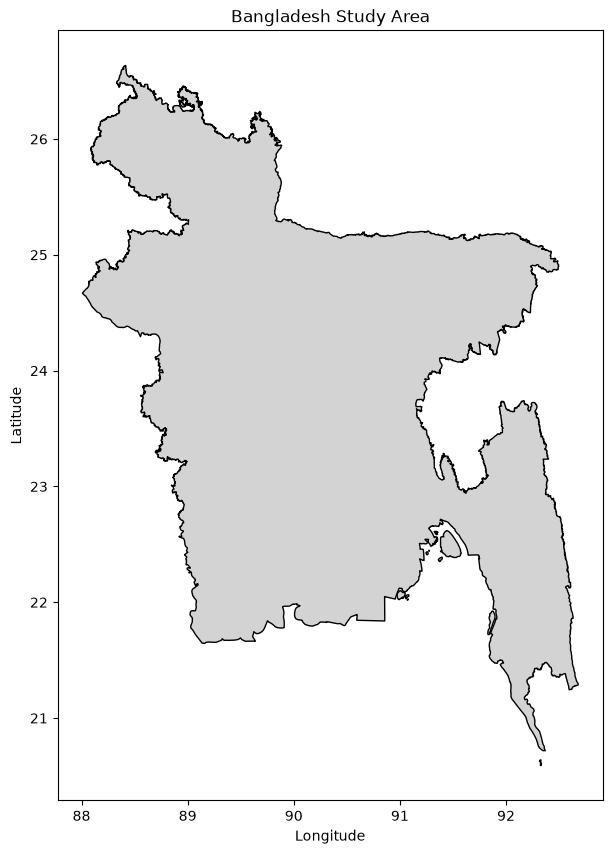

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 10))

aoi.plot(
    ax=ax,
    facecolor="lightgray",
    edgecolor="black"
)

ax.set_title("Bangladesh Study Area")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

In [10]:
print("Valid geometry:", aoi.is_valid.all())

Valid geometry: True


In [11]:
from pystac_client import Client

catalog = Client.open(
    "https://earth-search.aws.element84.com/v1"
)

search = catalog.search(
    collections=["sentinel-2-c1-l2a"],
    bbox=[west, south, east, north],
    datetime="2025-01-01/2025-03-31",
    query={
        "eo:cloud_cover": {"lt": 10}
    }
)

items = search.item_collection()

print("Number of Sentinel-2 scenes:", len(items))

Number of Sentinel-2 scenes: 984


In [12]:
for item in items[:10]:
    print(
        item.id,
        item.datetime,
        item.properties.get("eo:cloud_cover")
    )

S2C_T45QZC_20250331T043543_L2A 2025-03-31 04:43:12.323000+00:00 2.461077
S2C_T46QBH_20250331T043543_L2A 2025-03-31 04:43:12.023000+00:00 1.484524
S2C_T46QCH_20250331T043543_L2A 2025-03-31 04:43:10.174000+00:00 2.454029
S2C_T45QZD_20250331T043543_L2A 2025-03-31 04:43:04.737000+00:00 3.250524
S2C_T46QBJ_20250331T043543_L2A 2025-03-31 04:43:03.688000+00:00 2.282882
S2C_T45RYJ_20250331T043543_L2A 2025-03-31 04:41:54.933000+00:00 3.637306
S2C_T45RYK_20250331T043543_L2A 2025-03-31 04:41:42.062000+00:00 2.380944
S2C_T46RCQ_20250331T043543_L2A 2025-03-31 04:41:33.505000+00:00 2.8266
S2C_T46RDQ_20250331T043543_L2A 2025-03-31 04:41:29.489000+00:00 9.006131
S2B_T45QWC_20250329T044853_L2A 2025-03-29 04:53:03.256000+00:00 8.480118


In [13]:
print(items[0].assets.keys())

dict_keys(['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededge1', 'swir16', 'wvp', 'nir08', 'scl', 'aot', 'coastal', 'nir09', 'cloud', 'snow', 'preview', 'granule_metadata', 'tileinfo_metadata', 'product_metadata', 'thumbnail'])


In [14]:
from shapely.geometry import shape

bd_geom = aoi.geometry.iloc[0]

items_bd = []

for item in items:
    scene_geom = shape(item.geometry)

    if scene_geom.intersects(bd_geom):
        items_bd.append(item)

print("Before filtering:", len(items))
print("After Bangladesh polygon filtering:", len(items_bd))

Before filtering: 984
After Bangladesh polygon filtering: 634


In [15]:
from collections import Counter

# Unique acquisition dates
dates = sorted(set(
    item.datetime.date()
    for item in items_bd
))

print("Unique acquisition dates:", len(dates))
print("First dates:", dates[:20])

# CRS distribution
epsg_counts = Counter(
    item.properties.get("proj:epsg")
    for item in items_bd
)

print("\nEPSG distribution:")
print(epsg_counts)

Unique acquisition dates: 51
First dates: [datetime.date(2025, 1, 2), datetime.date(2025, 1, 3), datetime.date(2025, 1, 5), datetime.date(2025, 1, 7), datetime.date(2025, 1, 10), datetime.date(2025, 1, 12), datetime.date(2025, 1, 13), datetime.date(2025, 1, 15), datetime.date(2025, 1, 17), datetime.date(2025, 1, 18), datetime.date(2025, 1, 20), datetime.date(2025, 1, 22), datetime.date(2025, 1, 25), datetime.date(2025, 1, 27), datetime.date(2025, 1, 28), datetime.date(2025, 1, 30), datetime.date(2025, 2, 1), datetime.date(2025, 2, 2), datetime.date(2025, 2, 4), datetime.date(2025, 2, 6)]

EPSG distribution:
Counter({None: 634})


In [16]:
for item in items_bd[:15]:
    print(
        item.id,
        "| Date:", item.datetime.date(),
        "| EPSG:", item.properties.get("proj:epsg"),
        "| Cloud:", round(item.properties.get("eo:cloud_cover"), 2)
    )

S2C_T45RYJ_20250331T043543_L2A | Date: 2025-03-31 | EPSG: None | Cloud: 3.64
S2B_T45QXE_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.24
S2B_T45QYE_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 6.95
S2B_T45QXF_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.0
S2B_T45QYF_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.0
S2B_T45QXG_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.01
S2B_T45QYG_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.11
S2B_T45RWH_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.18
S2B_T45RXH_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.02
S2B_T45RYH_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.05
S2B_T45RZH_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0
S2B_T45RWJ_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0.01
S2B_T46RBN_20250329T044853_L2A | Date: 2025-03-29 | EPSG: None | Cloud: 0
S2B_T45

In [17]:
item = items_bd[0]

for key, value in item.properties.items():
    if "proj" in key.lower():
        print(key, ":", value)

proj:centroid : {'lat': 25.6352, 'lon': 89.93019}
proj:code : EPSG:32645


In [18]:
print("Item ID:", item.id)

print("\nProjection-related properties:")
for k in item.properties.keys():
    if "proj" in k.lower() or "mgrs" in k.lower():
        print(k, "=", item.properties[k])

Item ID: S2C_T45RYJ_20250331T043543_L2A

Projection-related properties:
proj:centroid = {'lat': 25.6352, 'lon': 89.93019}
mgrs:utm_zone = 45
mgrs:latitude_band = R
mgrs:grid_square = YJ
proj:code = EPSG:32645


In [19]:
from collections import defaultdict

items_by_tile = defaultdict(list)

for item in items_bd:
    tile_id = item.id.split("_")[1]

    items_by_tile[tile_id].append(item)

In [20]:
selected_items = []

N_BEST = 5

for tile_id, tile_items in items_by_tile.items():

    tile_items_sorted = sorted(
        tile_items,
        key=lambda x: x.properties.get(
            "eo:cloud_cover",
            100
        )
    )

    selected_items.extend(
        tile_items_sorted[:N_BEST]
    )

print("Original items:", len(items_bd))
print("Selected items:", len(selected_items))

Original items: 634
Selected items: 180


In [21]:
selected_tile_counts = Counter(
    item.id.split("_")[1]
    for item in selected_items
)

print(selected_tile_counts)

Counter({'T45RYJ': 5, 'T45QXE': 5, 'T45QYE': 5, 'T45QXF': 5, 'T45QYF': 5, 'T45QXG': 5, 'T45QYG': 5, 'T45RWH': 5, 'T45RXH': 5, 'T45RYH': 5, 'T45RZH': 5, 'T45RWJ': 5, 'T46RBN': 5, 'T45RXJ': 5, 'T45RZJ': 5, 'T46RBP': 5, 'T46QDH': 5, 'T46QCJ': 5, 'T46QDJ': 5, 'T46QCK': 5, 'T46QDK': 5, 'T46QCL': 5, 'T46QDL': 5, 'T46QCM': 5, 'T46QDM': 5, 'T46RCN': 5, 'T46RDN': 5, 'T45QYD': 5, 'T45QZE': 5, 'T46QBK': 5, 'T45QZF': 5, 'T46QBL': 5, 'T45QZG': 5, 'T46QBM': 5, 'T45RXK': 5, 'T45RYK': 5})


In [22]:
import geopandas as gpd
from shapely.geometry import shape
from shapely.ops import unary_union

# Selected item footprints
selected_geoms = [
    shape(item.geometry)
    for item in selected_items
]

# Merge all selected Sentinel footprints
selected_union = unary_union(selected_geoms)

# Bangladesh geometry
bd_geom = aoi.geometry.iloc[0]

# Bangladesh area covered by selected tiles
covered_geom = bd_geom.intersection(selected_union)

# Equal-area projection for area calculation
coverage_gdf = gpd.GeoDataFrame(
    geometry=[
        bd_geom,
        covered_geom
    ],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

bd_area = coverage_gdf.geometry.iloc[0].area
covered_area = coverage_gdf.geometry.iloc[1].area

coverage_percent = (
    covered_area / bd_area
) * 100

print(
    f"Bangladesh coverage: "
    f"{coverage_percent:.4f}%"
)

Bangladesh coverage: 96.0360%


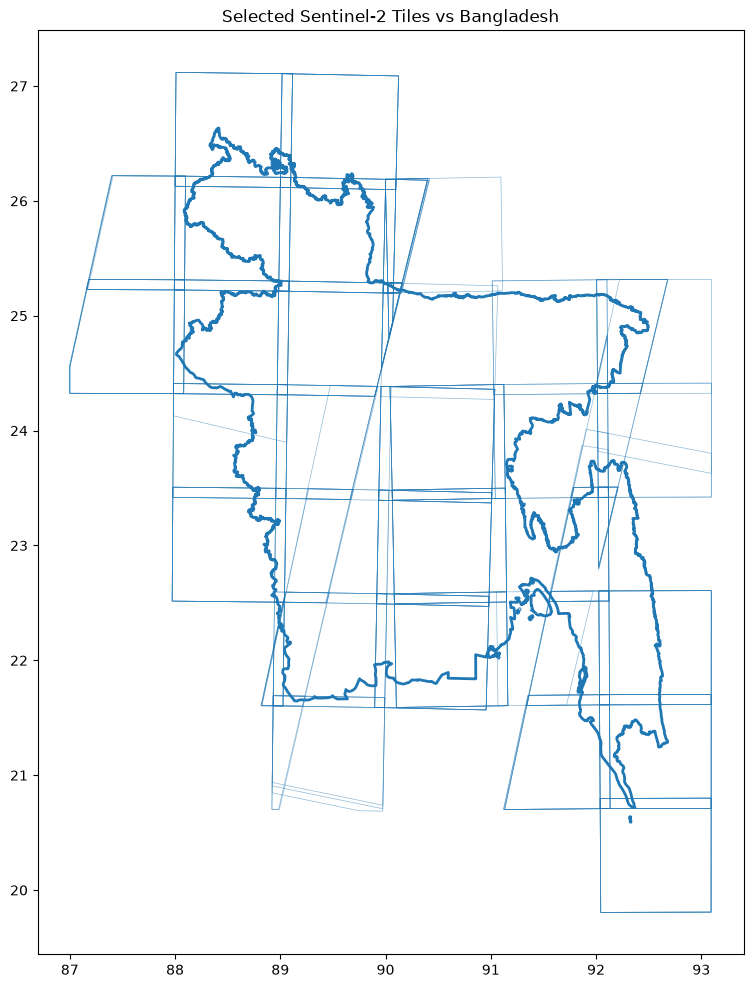

In [23]:
selected_tiles_gdf = gpd.GeoDataFrame(
    geometry=selected_geoms,
    crs="EPSG:4326"
)

fig, ax = plt.subplots(
    figsize=(10, 12)
)

selected_tiles_gdf.boundary.plot(
    ax=ax,
    linewidth=0.5,
    alpha=0.5
)

aoi.boundary.plot(
    ax=ax,
    linewidth=2
)

ax.set_title(
    "Selected Sentinel-2 Tiles vs Bangladesh"
)

plt.show()

In [24]:
from collections import defaultdict
from shapely.geometry import shape
from shapely.ops import unary_union

# Group all Bangladesh-intersecting scenes by MGRS tile
items_by_tile = defaultdict(list)

for item in items_bd:
    tile_id = item.id.split("_")[1]
    items_by_tile[tile_id].append(item)

print("Unique tiles:", len(items_by_tile))

Unique tiles: 36


In [25]:
tile_footprints = {}

for tile_id, tile_items in items_by_tile.items():
    tile_footprints[tile_id] = shape(tile_items[0].geometry)

In [26]:
all_tile_union = unary_union(
    list(tile_footprints.values())
)

covered_all = bd_geom.intersection(all_tile_union)

coverage_check = gpd.GeoDataFrame(
    geometry=[
        bd_geom,
        covered_all
    ],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

bd_area = coverage_check.geometry.iloc[0].area
covered_area = coverage_check.geometry.iloc[1].area

coverage_percent_all = (
    covered_area / bd_area
) * 100

print(
    f"Coverage using ALL unique tiles: "
    f"{coverage_percent_all:.4f}%"
)

Coverage using ALL unique tiles: 71.5187%


In [27]:
from shapely.geometry import shape
from shapely.ops import unary_union
import geopandas as gpd

# Bangladesh geometry
bd_geom = aoi.geometry.iloc[0]

# ALL 634 Sentinel scene footprints
all_scene_geoms = [
    shape(item.geometry)
    for item in items_bd
]

# Union of every available footprint
all_scene_union = unary_union(all_scene_geoms)

# Only the part inside Bangladesh
covered_geom = bd_geom.intersection(all_scene_union)

# Equal-area CRS for area calculation
coverage_gdf = gpd.GeoDataFrame(
    {
        "type": [
            "Bangladesh",
            "Covered"
        ]
    },
    geometry=[
        bd_geom,
        covered_geom
    ],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

bd_area = coverage_gdf.geometry.iloc[0].area
covered_area = coverage_gdf.geometry.iloc[1].area

coverage_percent = (
    covered_area / bd_area
) * 100

print(
    f"Coverage using ALL 634 scenes: "
    f"{coverage_percent:.4f}%"
)

Coverage using ALL 634 scenes: 100.0000%


In [28]:
from collections import defaultdict
from shapely.geometry import shape
from shapely.ops import unary_union

# Group by MGRS tile
items_by_tile = defaultdict(list)

for item in items_bd:
    tile_id = item.id.split("_")[1]
    items_by_tile[tile_id].append(item)

selected_items = []

N_BEST = 5

for tile_id, tile_items in items_by_tile.items():

    tile_items_sorted = sorted(
        tile_items,
        key=lambda x: x.properties.get("eo:cloud_cover", 100)
    )

    selected_items.extend(
        tile_items_sorted[:N_BEST]
    )

print("Initial selected scenes:", len(selected_items))

Initial selected scenes: 180


In [29]:
selected_union = unary_union([
    shape(item.geometry)
    for item in selected_items
])

covered = bd_geom.intersection(selected_union)

coverage_check = gpd.GeoDataFrame(
    geometry=[bd_geom, covered],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

coverage = (
    coverage_check.geometry.iloc[1].area /
    coverage_check.geometry.iloc[0].area
) * 100

print(f"Initial coverage: {coverage:.4f}%")

Initial coverage: 96.0360%


In [30]:
missing_geom = bd_geom.difference(selected_union)

print("Missing geometry empty:", missing_geom.is_empty)

Missing geometry empty: False


In [31]:
# IDs already selected
selected_ids = {item.id for item in selected_items}

# Remaining scenes
remaining_items = [
    item for item in items_bd
    if item.id not in selected_ids
]

# Better/cleaner scenes first
remaining_items = sorted(
    remaining_items,
    key=lambda x: x.properties.get("eo:cloud_cover", 100)
)

print("Remaining scenes:", len(remaining_items))

Remaining scenes: 454


In [32]:
from shapely.geometry import shape

added_items = []

for item in remaining_items:

    scene_geom = shape(item.geometry)

    # This scene covers any currently missing Bangladesh area?
    overlap = missing_geom.intersection(scene_geom)

    if not overlap.is_empty and overlap.area > 0:

        selected_items.append(item)
        added_items.append(item)

        # Update coverage
        selected_union = selected_union.union(scene_geom)

        # Recalculate missing Bangladesh area
        missing_geom = bd_geom.difference(selected_union)

        if missing_geom.is_empty:
            break

print("Extra scenes added:", len(added_items))
print("Final selected scenes:", len(selected_items))
print("Missing geometry empty:", missing_geom.is_empty)

Extra scenes added: 9
Final selected scenes: 189
Missing geometry empty: True


In [33]:
final_covered = bd_geom.intersection(selected_union)

final_check = gpd.GeoDataFrame(
    geometry=[
        bd_geom,
        final_covered
    ],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

final_coverage = (
    final_check.geometry.iloc[1].area
    / final_check.geometry.iloc[0].area
) * 100

print(f"Final Bangladesh coverage: {final_coverage:.6f}%")

Final Bangladesh coverage: 100.000000%


In [34]:
missing_gdf = gpd.GeoDataFrame(
    geometry=[missing_geom],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

missing_km2 = (
    missing_gdf.geometry.area.iloc[0]
    / 1_000_000
)

print(f"Remaining missing area: {missing_km2:.4f} km²")

Remaining missing area: 0.0000 km²


In [35]:
for item in added_items:
    print(
        item.id,
        "| Date:", item.datetime.date(),
        "| Cloud:",
        round(item.properties.get("eo:cloud_cover", 0), 2)
    )

S2B_T46QDL_20250204T043507_L2A | Date: 2025-02-04 | Cloud: 0
S2A_T46QDL_20250120T043656_L2A | Date: 2025-01-20 | Cloud: 0
S2B_T45RZH_20250118T044557_L2A | Date: 2025-01-18 | Cloud: 0
S2C_T46QDL_20250216T042320_L2A | Date: 2025-02-16 | Cloud: 0.0
S2B_T46QCL_20250326T043642_L2A | Date: 2025-03-26 | Cloud: 0.0
S2B_T45RZH_20250207T044842_L2A | Date: 2025-02-07 | Cloud: 0.0
S2B_T45RYH_20250207T044842_L2A | Date: 2025-02-07 | Cloud: 0.0
S2A_T45QZG_20250110T043408_L2A | Date: 2025-01-10 | Cloud: 0.01
S2B_T45RYH_20250214T043307_L2A | Date: 2025-02-14 | Cloud: 0.01


In [36]:
import stackstac

sentinel = stackstac.stack(
    selected_items,
    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],
    bounds_latlon=[
        west,
        south,
        east,
        north
    ],
    epsg=6933,
    resolution=100,
    chunksize=1024
)

print(sentinel)

<xarray.DataArray 'stackstac-a2e92237474ede8ebf8e0ab9d01673b9' (time: 189,
                                                                band: 5,
                                                                y: 7078, x: 4509)> Size: 241GB
dask.array<fetch_raster_window, shape=(189, 5, 7078, 4509), dtype=float64, chunksize=(1, 1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/54)
  * time                                     (time) datetime64[ns] 2kB 2025-0...
    id                                       (time) <U30 23kB 'S2A_T45RYK_202...
  * band                                     (band) <U6 120B 'green' ... 'scl'
  * x                                        (x) float64 36kB 8.492e+06 ... 8...
  * y                                        (y) float64 57kB 3.28e+06 ... 2....
    s2:high_proba_clouds_percentage          (time) object 2kB 1.441133 ... 0
    ...                                       ...
    gsd                                      (band) int64 40B 10 10 10 20 2

In [37]:
print("Dimensions:", sentinel.dims)
print("Shape:", sentinel.shape)
print("Bands:", sentinel.band.values)
print("CRS:", sentinel.attrs.get("crs"))

Dimensions: ('time', 'band', 'y', 'x')
Shape: (189, 5, 7078, 4509)
Bands: ['green' 'red' 'nir' 'swir16' 'scl']
CRS: epsg:6933


In [38]:
# 1. Get SCL band
scl = sentinel.sel(band="scl")

# 2. Define valid pixels
valid_pixels = ~scl.isin([
    0,   # No data
    1,   # Saturated / defective
    3,   # Cloud shadow
    8,   # Medium probability cloud
    9,   # High probability cloud
    10,  # Thin cirrus
    11   # Snow / ice
])

print(valid_pixels)

<xarray.DataArray 'stackstac-a2e92237474ede8ebf8e0ab9d01673b9' (time: 189,
                                                                y: 7078, x: 4509)> Size: 6GB
dask.array<invert, shape=(189, 7078, 4509), dtype=bool, chunksize=(1, 1024, 1024), chunktype=numpy.ndarray>
Coordinates: (12/54)
  * time                                     (time) datetime64[ns] 2kB 2025-0...
    id                                       (time) <U30 23kB 'S2A_T45RYK_202...
    band                                     <U6 24B 'scl'
  * x                                        (x) float64 36kB 8.492e+06 ... 8...
  * y                                        (y) float64 57kB 3.28e+06 ... 2....
    s2:high_proba_clouds_percentage          (time) object 2kB 1.441133 ... 0
    ...                                       ...
    gsd                                      int64 8B 20
    title                                    <U30 120B 'Scene classification ...
    common_name                              object 8B

In [39]:
green = sentinel.sel(band="green")
red = sentinel.sel(band="red")
nir = sentinel.sel(band="nir")
swir = sentinel.sel(band="swir16")

In [40]:
green_clean = green.where(valid_pixels)
red_clean = red.where(valid_pixels)
nir_clean = nir.where(valid_pixels)
swir_clean = swir.where(valid_pixels)

In [41]:
print("valid_pixels shape:", valid_pixels.shape)
print("green_clean shape:", green_clean.shape)

valid_pixels shape: (189, 7078, 4509)
green_clean shape: (189, 7078, 4509)


In [42]:
green_med = green_clean.median(
    dim="time",
    skipna=True
)

red_med = red_clean.median(
    dim="time",
    skipna=True
)

nir_med = nir_clean.median(
    dim="time",
    skipna=True
)

swir_med = swir_clean.median(
    dim="time",
    skipna=True
)

In [43]:
print(green_med)

<xarray.DataArray 'stackstac-a2e92237474ede8ebf8e0ab9d01673b9' (y: 7078, x: 4509)> Size: 255MB
dask.array<nanmedian, shape=(7078, 4509), dtype=float64, chunksize=(297, 297), chunktype=numpy.ndarray>
Coordinates: (12/13)
  * x                                        (x) float64 36kB 8.492e+06 ... 8...
  * y                                        (y) float64 57kB 3.28e+06 ... 2....
    storage:region                           <U9 36B 'us-west-2'
    processing:software                      object 8B {'sentinel-2-c1-l2a-to...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:processing_baseline                   <U5 20B '05.11'
    ...                                       ...
    storage:requester_pays                   bool 1B False
    instruments                              <U3 12B 'msi'
    constellation                            <U10 40B 'sentinel-2'
    s2:saturated_defective_pixel_percentage  int64 8B 0
    storage:platform                         <U3 12B 'AW

In [44]:
ndvi = (
    (nir_med - red_med) /
    (nir_med + red_med)
)

ndvi = ndvi.where(
    (nir_med + red_med) != 0
).clip(-1, 1)

In [45]:
ndbi = (
    (swir_med - nir_med) /
    (swir_med + nir_med)
)

ndbi = ndbi.where(
    (swir_med + nir_med) != 0
).clip(-1, 1)

In [46]:
mndwi = (
    (green_med - swir_med) /
    (green_med + swir_med)
)

mndwi = mndwi.where(
    (green_med + swir_med) != 0
).clip(-1, 1)

In [47]:
print(ndvi)
print(ndbi)
print(mndwi)

<xarray.DataArray 'stackstac-a2e92237474ede8ebf8e0ab9d01673b9' (y: 7078, x: 4509)> Size: 255MB
dask.array<clip, shape=(7078, 4509), dtype=float64, chunksize=(297, 297), chunktype=numpy.ndarray>
Coordinates: (12/13)
  * x                                        (x) float64 36kB 8.492e+06 ... 8...
  * y                                        (y) float64 57kB 3.28e+06 ... 2....
    storage:region                           <U9 36B 'us-west-2'
    processing:software                      object 8B {'sentinel-2-c1-l2a-to...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:processing_baseline                   <U5 20B '05.11'
    ...                                       ...
    storage:requester_pays                   bool 1B False
    instruments                              <U3 12B 'msi'
    constellation                            <U10 40B 'sentinel-2'
    s2:saturated_defective_pixel_percentage  int64 8B 0
    storage:platform                         <U3 12B 'AWS'
  

In [48]:
aoi_6933 = aoi.to_crs("EPSG:6933")

In [49]:
import rioxarray

ndvi = ndvi.rio.write_crs("EPSG:6933")
ndbi = ndbi.rio.write_crs("EPSG:6933")
mndwi = mndwi.rio.write_crs("EPSG:6933")

In [50]:
ndvi_bd = ndvi.rio.clip(
    aoi_6933.geometry,
    aoi_6933.crs,
    drop=True
)

ndbi_bd = ndbi.rio.clip(
    aoi_6933.geometry,
    aoi_6933.crs,
    drop=True
)

mndwi_bd = mndwi.rio.clip(
    aoi_6933.geometry,
    aoi_6933.crs,
    drop=True
)

In [51]:
print("NDVI:", ndvi_bd.shape)
print("NDBI:", ndbi_bd.shape)
print("MNDWI:", mndwi_bd.shape)

NDVI: (7077, 4508)
NDBI: (7077, 4508)
MNDWI: (7077, 4508)


In [52]:
def normalize_da(da, low, high):
    score = (da - low) / (high - low)
    return score.clip(0, 1)

In [53]:
ndbi_score = normalize_da(
    ndbi_bd,
    low=-0.3,
    high=0.4
)

In [54]:
ndvi_norm = normalize_da(
    ndvi_bd,
    low=0.0,
    high=0.7
)

nonveg_score = 1 - ndvi_norm

In [55]:
nonwater_mask = mndwi_bd < 0

In [56]:
builtup_score = (
    0.65 * ndbi_score
    + 0.35 * nonveg_score
)

In [57]:
builtup_score = builtup_score.where(
    nonwater_mask,
    0
)

builtup_score = builtup_score.clip(0, 1)

In [58]:
print(builtup_score)

<xarray.DataArray 'stackstac-a2e92237474ede8ebf8e0ab9d01673b9' (y: 7077, x: 4508)> Size: 255MB
dask.array<clip, shape=(7077, 4508), dtype=float64, chunksize=(297, 297), chunktype=numpy.ndarray>
Coordinates: (12/15)
  * x                                        (x) float64 36kB 8.492e+06 ... 8...
  * y                                        (y) float64 57kB 3.28e+06 ... 2....
    storage:region                           <U9 36B 'us-west-2'
    processing:software                      object 8B {'sentinel-2-c1-l2a-to...
    s2:datatake_type                         <U8 32B 'INS-NOBS'
    s2:processing_baseline                   <U5 20B '05.11'
    ...                                       ...
    constellation                            <U10 40B 'sentinel-2'
    s2:saturated_defective_pixel_percentage  int64 8B 0
    storage:platform                         <U3 12B 'AWS'
    gsd                                      int64 8B 20
    epsg                                     int64 8B 6933
    

In [59]:
import rasterio
import pyproj

print("Rasterio:", rasterio.__version__)
print("GDAL:", rasterio.__gdal_version__)
print("PyProj:", pyproj.__version__)
print("PROJ:", pyproj.proj_version_str)

from rasterio.crs import CRS

print(CRS.from_epsg(4326))
print(CRS.from_epsg(6933))

Rasterio: 1.4.4
GDAL: 3.10.3
PyProj: 3.7.2
PROJ: 9.5.1
EPSG:4326
EPSG:6933


In [60]:
import matplotlib.pyplot as plt

builtup_preview = builtup_score.coarsen(
    x=4,
    y=4,
    boundary="trim"
).mean()

plt.figure(figsize=(9, 11))

builtup_preview.plot(
    vmin=0,
    vmax=1
)

plt.title("Bangladesh Built-up Score")

plt.show()

RuntimeError: Error reading Window(col_off=1024, row_off=2048, width=1024, height=1024) from 'https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/45/R/YH/2025/2/S2B_T45RYH_20250227T044409_L2A/B11.tif': RasterioIOError('Read failed. See previous exception for details.')

<Figure size 900x1100 with 0 Axes>

In [61]:
bad_id = "S2B_T45RYH_20250227T044409_L2A"

selected_items_clean = [
    item for item in selected_items
    if item.id != bad_id
]

print("Before:", len(selected_items))
print("After :", len(selected_items_clean))

Before: 189
After : 188


In [62]:
from shapely.geometry import shape
from shapely.ops import unary_union
import geopandas as gpd

selected_union = unary_union([
    shape(item.geometry)
    for item in selected_items_clean
])

covered = bd_geom.intersection(selected_union)

check = gpd.GeoDataFrame(
    geometry=[bd_geom, covered],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

coverage = (
    check.geometry.iloc[1].area /
    check.geometry.iloc[0].area
) * 100

print(f"Coverage: {coverage:.6f}%")

Coverage: 100.000000%


In [63]:
sentinel = stackstac.stack(
    selected_items_clean,
    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],
    bounds_latlon=[
        west,
        south,
        east,
        north
    ],
    epsg=6933,
    resolution=100,
    chunksize=1024
)

In [64]:
scl = sentinel.sel(band="scl")

valid_pixels = ~scl.isin([
    0, 1, 3, 8, 9, 10, 11
])

green = sentinel.sel(band="green")
red   = sentinel.sel(band="red")
nir   = sentinel.sel(band="nir")
swir  = sentinel.sel(band="swir16")

In [65]:
bad_id = "S2B_T45RYH_20250227T044409_L2A"

selected_items_clean = [
    item for item in selected_items
    if item.id != bad_id
]

print("Final scenes:", len(selected_items_clean))

Final scenes: 188


In [66]:
sentinel = stackstac.stack(
    selected_items_clean,
    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],
    bounds_latlon=[
        west,
        south,
        east,
        north
    ],
    epsg=6933,
    resolution=100,
    chunksize=1024
)

print(sentinel.shape)

(188, 5, 7078, 4509)


In [67]:
scl = sentinel.sel(band="scl")

valid_pixels = ~scl.isin([
    0,
    1,
    3,
    8,
    9,
    10,
    11
])

In [68]:
green = sentinel.sel(band="green")
red   = sentinel.sel(band="red")
nir   = sentinel.sel(band="nir")
swir  = sentinel.sel(band="swir16")

In [69]:
green_clean = green.where(valid_pixels)
red_clean   = red.where(valid_pixels)
nir_clean   = nir.where(valid_pixels)
swir_clean  = swir.where(valid_pixels)

In [70]:
green_med = green_clean.median(dim="time", skipna=True)
red_med   = red_clean.median(dim="time", skipna=True)
nir_med   = nir_clean.median(dim="time", skipna=True)
swir_med  = swir_clean.median(dim="time", skipna=True)

In [71]:
ndvi = ((nir_med - red_med) / (nir_med + red_med)).clip(-1, 1)

ndbi = ((swir_med - nir_med) / (swir_med + nir_med)).clip(-1, 1)

mndwi = ((green_med - swir_med) / (green_med + swir_med)).clip(-1, 1)

In [72]:
aoi_6933 = aoi.to_crs("EPSG:6933")

ndvi = ndvi.rio.write_crs("EPSG:6933")
ndbi = ndbi.rio.write_crs("EPSG:6933")
mndwi = mndwi.rio.write_crs("EPSG:6933")

ndvi_bd = ndvi.rio.clip(
    aoi_6933.geometry,
    aoi_6933.crs,
    drop=True
)

ndbi_bd = ndbi.rio.clip(
    aoi_6933.geometry,
    aoi_6933.crs,
    drop=True
)

mndwi_bd = mndwi.rio.clip(
    aoi_6933.geometry,
    aoi_6933.crs,
    drop=True
)

In [73]:
def normalize_da(da, low, high):
    score = (da - low) / (high - low)
    return score.clip(0, 1)

In [74]:
ndbi_score = normalize_da(
    ndbi_bd,
    low=-0.3,
    high=0.4
)

ndvi_norm = normalize_da(
    ndvi_bd,
    low=0.0,
    high=0.7
)

nonveg_score = 1 - ndvi_norm

nonwater_mask = mndwi_bd < 0

In [75]:
builtup_score = (
    0.65 * ndbi_score
    +
    0.35 * nonveg_score
)

builtup_score = builtup_score.where(
    nonwater_mask,
    0
)

builtup_score = builtup_score.clip(0, 1)

In [76]:
builtup_preview = builtup_score.coarsen(
    x=4,
    y=4,
    boundary="trim"
).mean()

plt.figure(figsize=(9, 11))

builtup_preview.plot(
    vmin=0,
    vmax=1
)

plt.title("Bangladesh Built-up Score")

plt.show()

RuntimeError: Error reading Window(col_off=2048, row_off=4096, width=1024, height=1024) from 'https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/46/Q/BL/2025/3/S2B_T46QBL_20250326T043642_L2A/B11.tif': RasterioIOError('Read failed. See previous exception for details.')

<Figure size 900x1100 with 0 Axes>

In [77]:
import rasterio
from rasterio.windows import Window

bad_ids = []
good_ids = []

for i, item in enumerate(selected_items, start=1):

    scene_id = item.id
    swir_url = item.assets["swir16"].href

    try:
        with rasterio.open(swir_url) as src:

            # Small test window
            w = min(512, src.width)
            h = min(512, src.height)

            window = Window(
                col_off=0,
                row_off=0,
                width=w,
                height=h
            )

            _ = src.read(
                1,
                window=window
            )

        good_ids.append(scene_id)

        print(
            f"[{i}/{len(selected_items)}] OK  : {scene_id}"
        )

    except Exception as e:

        bad_ids.append(scene_id)

        print(
            f"[{i}/{len(selected_items)}] BAD : {scene_id}"
        )

        print(
            "   Error:",
            str(e)[:200]
        )

[1/189] OK  : S2B_T45RYJ_20250319T044836_L2A
[2/189] OK  : S2C_T45RYJ_20250304T044753_L2A
[3/189] OK  : S2B_T45RYJ_20250217T044600_L2A
[4/189] OK  : S2B_T45RYJ_20250309T044336_L2A
[5/189] OK  : S2C_T45RYJ_20250324T044302_L2A
[6/189] OK  : S2B_T45QXE_20250204T043507_L2A
[7/189] OK  : S2B_T45QXE_20250214T043307_L2A
[8/189] OK  : S2C_T45QXE_20250209T043345_L2A
[9/189] OK  : S2A_T45QXE_20250120T043656_L2A
[10/189] OK  : S2B_T45QXE_20250326T043642_L2A
[11/189] OK  : S2B_T45QYE_20250207T044842_L2A
[12/189] OK  : S2B_T45QYE_20250306T043954_L2A
[13/189] OK  : S2B_T45QYE_20250214T043307_L2A
[14/189] OK  : S2B_T45QYE_20250118T044557_L2A
[15/189] OK  : S2A_T45QYE_20250120T043656_L2A
[16/189] OK  : S2C_T45QXF_20250304T044753_L2A
[17/189] OK  : S2A_T45QXF_20250316T044231_L2A
[18/189] OK  : S2B_T45QXF_20250128T045121_L2A
[19/189] OK  : S2B_T45QXF_20250207T044842_L2A
[20/189] OK  : S2B_T45QXF_20250329T044853_L2A
[21/189] OK  : S2B_T45QYF_20250329T044853_L2A
[22/189] OK  : S2B_T45QYF_20250207T044842_L

In [78]:
print("\n====================")
print("TEST COMPLETE")
print("====================")

print("Total scenes :", len(selected_items))
print("Good scenes  :", len(good_ids))
print("Bad scenes   :", len(bad_ids))

print("\nBad scene IDs:")

for scene_id in bad_ids:
    print(scene_id)


TEST COMPLETE
Total scenes : 189
Good scenes  : 189
Bad scenes   : 0

Bad scene IDs:


In [83]:
from shapely.geometry import shape
from shapely.ops import unary_union
import geopandas as gpd

clean_union = unary_union([
    shape(item.geometry)
    for item in selected_items_clean
])

covered = bd_geom.intersection(
    clean_union
)

coverage_gdf = gpd.GeoDataFrame(
    geometry=[
        bd_geom,
        covered
    ],
    crs="EPSG:4326"
).to_crs("EPSG:6933")

coverage = (
    coverage_gdf.geometry.iloc[1].area /
    coverage_gdf.geometry.iloc[0].area
) * 100

print(
    f"Bangladesh coverage after removing bad scenes: "
    f"{coverage:.6f}%"
)

Bangladesh coverage after removing bad scenes: 100.000000%


In [84]:
import stackstac

sentinel = stackstac.stack(
    selected_items_clean,

    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],

    bounds_latlon=[
        west,
        south,
        east,
        north
    ],

    epsg=6933,
    resolution=100,
    chunksize=512
)

print(sentinel)

<xarray.DataArray 'stackstac-b5f7e56962785fb23381dc31e5385fca' (time: 188,
                                                                band: 5,
                                                                y: 7078, x: 4509)> Size: 240GB
dask.array<fetch_raster_window, shape=(188, 5, 7078, 4509), dtype=float64, chunksize=(1, 1, 512, 512), chunktype=numpy.ndarray>
Coordinates: (12/54)
  * time                                     (time) datetime64[ns] 2kB 2025-0...
    id                                       (time) <U30 23kB 'S2A_T45RYK_202...
  * band                                     (band) <U6 120B 'green' ... 'scl'
  * x                                        (x) float64 36kB 8.492e+06 ... 8...
  * y                                        (y) float64 57kB 3.28e+06 ... 2....
    s2:high_proba_clouds_percentage          (time) object 2kB 1.441133 ... 0
    ...                                       ...
    gsd                                      (band) int64 40B 10 10 10 20 20


In [85]:
sentinel = stackstac.stack(
    selected_items,
    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],
    bounds_latlon=[west, south, east, north],
    epsg=6933,
    resolution=100,
    chunksize=256
)

In [86]:
scl = sentinel.sel(band="scl")

valid_pixels = ~scl.isin([
    0, 1, 3, 8, 9, 10, 11
])

green = sentinel.sel(band="green").where(valid_pixels)
red   = sentinel.sel(band="red").where(valid_pixels)
nir   = sentinel.sel(band="nir").where(valid_pixels)
swir  = sentinel.sel(band="swir16").where(valid_pixels)

green_med = green.median("time", skipna=True)
red_med   = red.median("time", skipna=True)
nir_med   = nir.median("time", skipna=True)
swir_med  = swir.median("time", skipna=True)

In [87]:
ndvi = ((nir_med - red_med) / (nir_med + red_med)).clip(-1, 1)

ndbi = ((swir_med - nir_med) / (swir_med + nir_med)).clip(-1, 1)

mndwi = ((green_med - swir_med) / (green_med + swir_med)).clip(-1, 1)

In [88]:
test_ndbi = ndbi.isel(
    x=slice(1500, 1800),
    y=slice(2500, 2800)
)

test_result = test_ndbi.compute()

print(test_result)

RuntimeError: Error reading Window(col_off=1792, row_off=2560, width=256, height=256) from 'https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/45/Q/YG/2025/2/S2B_T45QYG_20250214T043307_L2A/B08.tif': RasterioIOError('Read failed. See previous exception for details.')

In [89]:
sentinel = stackstac.stack(
    selected_items,
    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],
    bounds_latlon=[west, south, east, north],
    epsg=6933,
    resolution=100,
    chunksize=256
)

In [90]:
scl = sentinel.sel(band="scl")

valid_pixels = ~scl.isin([
    0, 1, 3, 8, 9, 10, 11
])

green = sentinel.sel(band="green").where(valid_pixels)
red   = sentinel.sel(band="red").where(valid_pixels)
nir   = sentinel.sel(band="nir").where(valid_pixels)
swir  = sentinel.sel(band="swir16").where(valid_pixels)

green_med = green.median("time", skipna=True)
red_med   = red.median("time", skipna=True)
nir_med   = nir.median("time", skipna=True)
swir_med  = swir.median("time", skipna=True)

In [91]:
ndvi = ((nir_med - red_med) / (nir_med + red_med)).clip(-1, 1)

ndbi = ((swir_med - nir_med) / (swir_med + nir_med)).clip(-1, 1)

mndwi = ((green_med - swir_med) / (green_med + swir_med)).clip(-1, 1)

In [93]:
from collections import defaultdict

items_by_tile = defaultdict(list)

for item in selected_items:
    tile_id = item.id.split("_")[1]
    items_by_tile[tile_id].append(item)

print("Number of tiles:", len(items_by_tile))

Number of tiles: 36


In [94]:
tile_id = list(items_by_tile.keys())[0]

tile_items = items_by_tile[tile_id]

print(tile_id, len(tile_items))

T45RYJ 5


In [95]:
tile_stack = stackstac.stack(
    tile_items,
    assets=[
        "green",
        "red",
        "nir",
        "swir16",
        "scl"
    ],
    epsg=6933,
    resolution=100,
    chunksize=256
)

print(tile_stack)

<xarray.DataArray 'stackstac-815c2403befe0020bf49cedf08674df1' (time: 5,
                                                                band: 5,
                                                                y: 1164, x: 1076)> Size: 250MB
dask.array<fetch_raster_window, shape=(5, 5, 1164, 1076), dtype=float64, chunksize=(1, 1, 256, 256), chunktype=numpy.ndarray>
Coordinates: (12/54)
  * time                                     (time) datetime64[ns] 40B 2025-0...
    id                                       (time) <U30 600B 'S2B_T45RYJ_202...
  * band                                     (band) <U6 120B 'green' ... 'scl'
  * x                                        (x) float64 9kB 8.586e+06 ... 8....
  * y                                        (y) float64 9kB 3.231e+06 ... 3....
    s2:high_proba_clouds_percentage          (time) object 40B 0 ... 0.001556
    ...                                       ...
    gsd                                      (band) int64 40B 10 10 10 20 20
    

In [96]:
scl = tile_stack.sel(band="scl")

valid = ~scl.isin([
    0, 1, 3, 8, 9, 10, 11
])

green = tile_stack.sel(band="green").where(valid)
red   = tile_stack.sel(band="red").where(valid)
nir   = tile_stack.sel(band="nir").where(valid)
swir  = tile_stack.sel(band="swir16").where(valid)

In [97]:
green_med = green.median("time", skipna=True)
red_med   = red.median("time", skipna=True)
nir_med   = nir.median("time", skipna=True)
swir_med  = swir.median("time", skipna=True)

In [98]:
ndvi_tile = (
    (nir_med - red_med) /
    (nir_med + red_med)
).clip(-1, 1)

ndbi_tile = (
    (swir_med - nir_med) /
    (swir_med + nir_med)
).clip(-1, 1)

mndwi_tile = (
    (green_med - swir_med) /
    (green_med + swir_med)
).clip(-1, 1)

In [99]:
ndbi_tile_loaded = ndbi_tile.compute()

RuntimeError: Error reading Window(col_off=0, row_off=0, width=256, height=256) from 'https://e84-earth-search-sentinel-data.s3.us-west-2.amazonaws.com/sentinel-2-c1-l2a/45/R/YJ/2025/3/S2C_T45RYJ_20250324T044302_L2A/B08.tif': RasterioIOError('Read failed. See previous exception for details.')